# [1교시]

### multimodal

## 전처리
- PDF 문서에서 텍스트와 이미지를 분리하여 추출하고 OpenAI를 이용해 이미지를 텍스트로 요약

In [1]:
# !pip install PyMuPDF

In [2]:
import os
import fitz # PyMuPDF
import requests
import base64
from dotenv import load_dotenv
from openai import OpenAI
load_dotenv(override=True)
client = OpenAI()

In [3]:
pdf_url = 'https://arxiv.org/pdf/1706.03762.pdf'
pdf_path = 'sample_paper.pdf'
if not os.path.exists(pdf_path):
    response = requests.get(pdf_url)
    with open(pdf_path, 'wb') as f:
        f.write(response.content)
    print('다운로드 완료')
else:
    print(f'{pdf_path} 가 존재합니다.')


sample_paper.pdf 가 존재합니다.


## pdf에서 텍스트와 이미지 추출

In [4]:
doc = fitz.open(pdf_path)
texts = []
images = []
output_img_dir = 'extracted_images'
os.makedirs(output_img_dir, exist_ok=True)
for page_num in range(len(doc)):
    page = doc.load_page(page_num)
    # 텍스트 추출
    text = page.get_text()
    if text.strip():
        texts.append({'page':page_num,'content':text})
    # 이미지 추출
    image_list = page.get_images(full=True)
    for image_index, img in  enumerate(image_list):
        xref = img[0]
        base_image =  doc.extract_image(xref)
        image_bytes = base_image['image']
        image_ext = base_image['ext']

        image_filename = f'page{page_num}_img{image_index+1}.{image_ext}'
        image_filepath = os.path.join(output_img_dir,image_filename)
        
        with open(image_filepath,'wb') as f:
            f.write(image_bytes)
        images.append({
            'page':page_num+1,
            'filename':image_filepath,
            'bytes':image_bytes,
            'ext':image_ext
        })
print(f'추출완료 : 텍스트 : {len(texts)}페이지, 이미지:{len(images)}개')

추출완료 : 텍스트 : 15페이지, 이미지:3개


## 이미지 요약 gpt-5.4-nano
- 이미지에 대한 상세 설명을 텍스트로 요약

In [5]:
def encode_image(image_bytes):
    return base64.b64encode(image_bytes).decode('utf-8')

image_summaries = []
for img_meta in images:
    base64_image = encode_image(img_meta['bytes'])
    ext = img_meta['ext']
    if ext.lower() =='jb2':
        ext = 'jpeg'
    mime_type = f'image/{ext}' if ext.lower() != "jpg" else 'image/jpeg'
    try:
        response = client.chat.completions.create(
            model = 'gpt-5.4-nano',
            messages=[
                {'role':'user', 
                 'content': [
                     {'type':'text', 'text':'이 이미지에 대한 상세한 설명을 작성해 주세요'},
                     {'type':'image_url', 'image_url':{
                         'url':f'data:{mime_type};base64,{base64_image}'
                         }
                      }
                 ]
                 }
            ],
            max_completion_tokens=300
        )
        summary = response.choices[0].message.content
        image_summaries.append({
            'filename':img_meta['filename'],
            'summary' : summary
        })
        print(f"[{img_meta['filename']}] 요약완료")
    except Exception as e:
        print(f"[{img_meta['filename']}] 요약실패 : {e}")

[extracted_images\page2_img1.png] 요약완료
[extracted_images\page3_img1.png] 요약완료
[extracted_images\page3_img2.png] 요약완료


In [6]:
# !pip install matplotlib

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
def show_img_summarize(index):
    img = Image.open('extracted_images/page3_img1.png')
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    print(image_summaries[1]['filename'])
    print(image_summaries[1]['summary'])

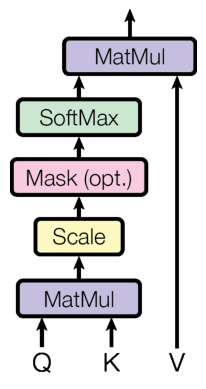

extracted_images\page3_img1.png
이미지는 **신경망(특히 Transformer 계열)의 어텐션(Attention) 계산 흐름**을 시각적으로 나타낸 도식입니다. 전체적으로 위쪽에서 아래쪽으로(또는 연산 순서대로) 모듈들이 쌓여 있고, 각 블록 사이에는 데이터 흐름을 의미하는 **굵은 검은 화살표**가 그려져 있습니다. 오른쪽에는 입력/출력 형태의 심볼이 표시되어 있습니다.

---

## 1) 입력(하단)
- 맨 아래에는 세 개의 기호가 있습니다.
  - **Q**: Query(질의)
  - **K**: Key(키)
  - **V**: Value(값)
- 이들은 보통 어텐션에서 **Q-K의 유사도를 계산해 가중치를 만들고, 그 가중치를 V에 적용**하는 역할을 합니다.

---

## 2) Scale 블록
- **Q와 K로부터 계산된 결과**가 **Scale** 단계로 들어갑니다.
- Scale 블록은 노란색 사각형(라운드 처리)으로 표시되어 있으며, 보통 Transformer에서는 **기본적으로 \( \sqrt{d_k} \)** 로 나누어 스케일링하는 과정을 뜻합니다.  
  (그림에서는 “Scale”이라는 텍스트가 해당 블록에 적혀 있습니다


In [9]:
show_img_summarize(2)

# [2교시]

### multimodal_RAG

In [13]:
import os
import fitz
from dotenv import load_dotenv
from openai import OpenAI
import chromadb
from chromadb.utils import embedding_functions

In [15]:
# 환경변수 로드 및 openai 클라이언트 생성
load_dotenv(override=True)
client = OpenAI()

In [53]:
# 벡터 Db 초기화
chroma_client = chromadb.PersistentClient(path='./chroma_db')
openai_ef = embedding_functions.OpenAIEmbeddingFunction(
    api_key=os.getenv('OPENAI_API_KEY'),
    model_name = 'text-embedding-3-small'
)
if chroma_client.count_collections() != 0:
    chroma_client.delete_collection('multimodal_rag')
collection = chroma_client.get_or_create_collection(name='multimodal_rag',embedding_function=openai_ef)
print(f'설정완료 현재 컬렉션의 크기 : {collection.count()}')

설정완료 현재 컬렉션의 크기 : 0


## 데이터 임베딩(텍스트 + 이미지 요약본)
- pdf의 텍스트와 이미지 요약본을 모두 VectorDB에 삽입(동일한 벡터공간에 텍스트와 이미지 요약본이 함께 존재)

In [ ]:
import base64
if collection.count() == 0:
    pdf_path = 'sample_paper.pdf'
    doc = fitz.open(pdf_path)
    documents = []
    metatdatas = []    
    ids = []
    
    for page_num in range(len(doc)):
        page = doc.load_page(page_num)
        # 텍스트 추출
        text = page.get_text()
        if text.strip():
            documents.append(text)
            metatdatas.append({'page':page_num+1,'type':'text'})
            ids.append(f'text_page_{page_num+1}')
        # 이미지 요약 후 추출
        image_list = page.get_images(full=True)
        if image_list:
            xref = image_list[0][0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image['image']
            ext = base_image['ext']
            if ext.lower() == 'jb2': ext = 'jpeg'
            mime_type = f'image/{ext}' if ext.lower() != "jpg" else 'image/jpeg'
            base64_image = base64.b64encode(image_bytes).decode('utf-8')
            try:
                response = client.chat.completions.create(
                    model = 'gpt-5.4-nano',
                    messages=[
                        {'role':'user', 
                        'content': [
                            {'type':'text', 'text':'이 이미지에 대한 상세한 설명을 작성해 주세요. 전문적이고 구체적으로 분석해야 합니다.'},
                            {'type':'image_url', 'image_url':{
                                'url':f'data:{mime_type};base64,{base64_image}'
                                }
                            }
                        ]
                        }
                    ],
                    # max_completion_tokens=300
                )
                summary = response.choices[0].message.content
                documents.append(summary)
                metatdatas.append({
                    'type':'image_summary',
                    'page':page_num+1,
                    'image_base64' : base64_image,  # 데이터가 큰 이미지를 자체적으로 저장하지말고 경로만 저장하는게 안전하다.(로컬에 저장하고 불러오기)
                    'mime_type':mime_type

                })
                ids.append(f'image_summary_page_{page_num+1}')
            except Exception as e:
                pass
    if documents:
        collection.add(documents=documents,metadatas=metatdatas,ids=ids)
        print('VectorDB에 데이터 임베딩 및 저장 완료')
else:
    print(f'vectorDB에 이미 {collection.count()}개 데이터가 존재합니다')

VectorDB에 데이터 임베딩 및 저장 완료


In [55]:
collection.count()

17

# [3교시]

## 질문을 통해 RAG 검색하기

아래 이미지는 **Transformer(트랜스포머) 모델의 인코더-디코더 구조**를 개념적으로 도식화한 것입니다. “입력 임베딩 → 인코더(여러 층) → 디코더(마스킹된 디코더 입력 포함) → 선형 변환 → Softmax로 확률 산출”의 흐름을 시각적으로 보여줍니다.

---

## 1) 전체 구성(좌측 인코더, 우측 디코더)
- **좌측(Encoder)**: 입력 시퀀스를 처리해 문맥(context) 표현을 만드는 부분입니다.
- **우측(Decoder)**: 인코더의 출력과, 이전에 생성된 토큰(오른쪽으로 이동된 입력)을 바탕으로 다음 토큰을 예측합니다.
- 가운데 위로 올라가는 화살표와 큰 라운드 박스들은 **두 컴포넌트가 서로 정보를 주고받는 구조**임을 나타냅니다.

---

## 2) 입력 계층: Embedding + Positional Encoding
### (1) Input Embedding
- 하단의 분홍색 박스 **“Input Embedding”**: 토큰(단어/서브워드)을 **연속 벡터(embedding)**로 바꿉니다.
- 화살표 “Inputs”가 이 임베딩으로 들어가며, 이는 **정수 토큰 인덱스 → 임베딩 벡터** 변환을 의미합니다.

### (2) Positional Encoding
- “Positional Encoding” 옆의 물결 아이콘(사인/파형 형태)은 **순서 정보**를 벡터에 더해 주는 역할을 표현합니다.
- 파형(또는 위치 인코딩)과 함께 **더하기(+) 기호**가 표시되어 있어, 보통
  \[
  \text{입력} = \text{Embedding} + \text{Positional Encoding}
  \]
  형태임을 보여줍니다.

---

## 3) Encoder 블록 내부 구조(좌측 큰 박스)
좌측 인코더는 상단으로 반복되는 **“N×”** 표기가 있어, 같은 형태의 층이 여러 번 쌓임을 뜻합니다.

### (1) Feed Forward 경로(파란 영역)
- **“Feed Forward”**라는 파란색 박스는 T

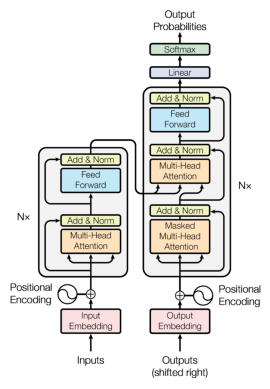

In [56]:
query = '논문에 나온 트랜스포커 아키텍처 다이어그램(인코더-디코더 그림)에 대해 설명해주세요'
results = collection.query(
    query_texts=[query],
    n_results=1
)
retrieved_docs = results['documents'][0][0]
retrieved_metas = results['metadatas'][0][0]
print(retrieved_docs)
# base64를 디코딩해서 출력
image_bytes = base64.b64decode(retrieved_metas['image_base64'])
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
img = Image.open(BytesIO(image_bytes))
plt.imshow(img)
plt.axis('off')
plt.show()


In [57]:
# query

# vector search

# image 발견

# LLM에 이미지와 사용자질문 이미지요약 설명

# 최종 답변

# [4교시]

### hf_multimodal_RAG

## Hugging Face
- 이미지 캡셔닝 : 'Salesforce/blip-image-captioning-base'
- 텍스트 임베딩 : 'sentence-transformers/all-MiniLM-L6-v2'
- 텍스트 생성: 'distilbert/distilgpt2'

In [59]:
import os
import fitz
import chromadb
from PIL import Image
from transformers import pipeline, BlipProcessor, BlipForConditionalGeneration
from chromadb.utils import embedding_functions

In [60]:
# BLIP 모델 로드
processor = BlipProcessor.from_pretrained('Salesforce/blip-image-captioning-base')
model = BlipForConditionalGeneration.from_pretrained('Salesforce/blip-image-captioning-base')

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [61]:
# 임베딩 모델 로드
hf_ef = embedding_functions.SentenceTransformerEmbeddingFunction(model_name='sentence-transformers/all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [62]:
# vectorDB 초기화
chroma_client = chromadb.PersistentClient(path='./chroma_db_hf')
collection = chroma_client.get_or_create_collection(name='multimodal_rag_hf', embedding_function=hf_ef)

## 데이터 추출 및 오픈소스 임베딩
- pdf 텍스트와 추출된 이미지를 BLIP 모델로 갭셔닝한 뒤, Sentence Transformers 임베딩을 사용해서 로컬 vectorDB에 저장

In [66]:
pdf_path = 'sample_paper.pdf'
if collection.count() == 0:
    doc = fitz.open(pdf_path)
    documents, metadatas, ids = [], [], []
    for page_num in range(len(doc)):
        page = doc.load_page(page_num)
        # 텍스트 추가
        text = page.get_text()
        if text.strip():
            documents.append(text)
            metadatas.append({'type':'text', 'page':'page_num+1'})
            ids.append(f'hf_text_page_{page_num+1}')
        # 이미지 캡셔닝
        image_lists = page.get_images(full=True)
        if image_lists:
            xref = image_lists[0][0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image['image']
            ext = base_image['ext']
            image_filename = f'hf_temp_img.{ext}'
            with open(image_filename, 'wb') as f:
                f.write(image_bytes)
            
            try:
                raw_image = Image.open(image_filename).convert('RGB')
                inputs = processor(raw_image, return_tensor='pt')
                out = model.generate(**inputs, max_new_tokens=50)
                caption = processor.decode(out[0], skip_special_tokens=True)

                documents.append(caption)
                metadatas.append({'type':'image_summary', 'page':page_num+1})
                ids.append(f'hf_image_summary_page_{page_num+1}')
                print(f'페이지 {page_num+1} 이미지 캡셔닝 완료 : {caption}')
            except Exception as e:
                print(f'페이지 {page_num+1} 이미지 캡셔닝 실패 : {e}')
    if documents:
        collection.add(documents=documents, metadatas=metadatas, ids=ids)
else:
    print(collection.count())

15


# [5교시]

In [67]:
query = 'what is transformer architecture?'
results = collection.query(
    query_texts=[query],
    n_results=1
)
retrieved_docs = results['documents'][0]
retrieved_metas = results['metadatas'][0]
print(f'검색된 문서 수 : {len(retrieved_docs)}')
for meta in retrieved_metas:
    print(f" - [출처:페이지{meta['page']}, 타입] : {meta['type']}")
context = '\n\n--\n\n'.join(retrieved_docs) 
print('\n오픈소스 답변 생성중\n')
generator = pipeline('text-generation', model='distilbert/distilgpt2')
prompt = f'Context:{context[:400]}\n\nQuestion:{query}\n\nAnswer:'
response = generator(prompt,max_new_tokens=100, num_return_sequences=1)
print('최종답변')
print(response[0]['generated_text'].replace(prompt, "").strip())

검색된 문서 수 : 1
 - [출처:페이지page_num+1, 타입] : text

오픈소스 답변 생성중



config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though

최종답변
What is the "current" stack or the "current" stack or the "current" stack or the "current" stack or the "current" stack or the "current" stack or the "current" stack or the "current" stack or the "current" stack or the "current" stack or the "current" stack or the "current" stack or the "current" stack or the "current" stack or the "current" stack or the "current" stack or the "


- RAG(이미지 인식 -> 임베딩 -> 검색 -> 답변생성) 가능
- 모델 성능차이... 경량화 모델인 BLIP는 문맥 이해력이 낮아서 반복적인 텍스트를 출력
- 향후 개선 : VRAM 확보, 이미지 인식 모델은 LLaVA-1.5 이상, 생성형 모델 Llama-3(8B) 수준으로 교체

In [69]:
# 필수 패키지 설치
# pip install langchain-community langchain-core ollama requests Pillow

# https://ollama.com/download/windows


# C:\Users\Playdata>ollama --version
# ollama version is 0.30.7

# C:\Users\Playdata>ollama pull llava:7b
# pulling manifest
# pulling 170370233dd5: 100% ▕█████████████████████████████████████████████████████████████████▏ 4.1 GB
# pulling 72d6f08a42f6: 100% ▕█████████████████████████████████████████████████████████████████▏ 624 MB
# pulling 43070e2d4e53: 100% ▕█████████████████████████████████████████████████████████████████▏  11 KB
# pulling c43332387573: 100% ▕█████████████████████████████████████████████████████████████████▏   67 B
# pulling ed11eda7790d: 100% ▕█████████████████████████████████████████████████████████████████▏   30 B
# pulling 7c658f9561e5: 100% ▕█████████████████████████████████████████████████████████████████▏  564 B
# verifying sha256 digest
# writing manifest
# success

# C:\Users\Playdata>ollama run llava:7b
# >>> 안녕하세요 당신은 무엇을 할수 있나요?
#  안녕하세요! 제가 할 수 있는 일은 질문에 대해 답변을 제공하고, 특정한 주제에 대해 자세한 설명을 할 수 있습니다.

# >>> /bye

```
[사용자 질문]
     ↓
[텍스트 → CLIP 임베딩]          ← embedder.py
     ↓
[ChromaDB 유사 이미지 검색]      ← vector_store.py
     ↓
[검색된 이미지 → Base64 인코딩]  ← utils.py
     ↓
[이미지 + 질문 → LLaVA 주입]    ← Phase A 서버
     ↓
[최종 답변 생성]
```

```
# 1. 가상환경 활성화


# 2. Ollama 서버 실행 확인
# 트레이 아이콘 확인 또는:
curl http://localhost:11434

# 3. 대화형 RAG 실행 (메인)
python rag_chat.py

# 4. 품질 비교 벤치마크 (선택)
pip install transformers     # BLIP 필요 시 추가 설치
python benchmark.py
```

```
전체 파이프라인 완성 요약
Phase           핵심파일                               역할
A           utils.py, test_image.py             Ollama 서버 + LLaVA 기본 연동
B           embedder.py, vector_store.py        CLIP 임베딩 + ChromaDB 저장/검색    
C           rag_pipeline.py, rag_chat.py        검색-생성 통합 + 대화형 인터페이스
C           benchmark.py                        LLaVA vs BLIP 품질 비교
```

# [6교시]

#  로컬 LLaVA 기반 고급 멀티모달 RAG

(경량 오픈소스 모델)을 넘어, ChatGPT-4o(Vision)에 필적하는 고성능 오픈소스 멀티모달 모델인 **LLaVA(Large Language-and-Vision Assistant)** 를 로컬 환경에 세팅하고 활용하는  계획입니다. 

---

## 1. LLaVA 로컬 세팅이란? (What & Why)

- **LLaVA란?**: 언어 모델(예: Llama-2/3, Vicuna)과 비전 인코더(CLIP)를 결합하여 이미지와 텍스트를 동시에 이해하는 대규모 멀티모달 오픈소스 모델입니다.
- **도입 목적**: 
  - **보안(Privacy)**: 사내 기밀 문서나 고객 데이터(이미지, 영수증 등)를 OpenAI 서버로 전송하지 않고 100% 로컬에서 처리 가능합니다.
  - **성능**: `BLIP`과 같은 경량 캡셔닝 모델과 달리, 복잡한 인포그래픽, 다이어그램, 수학 공식이 포함된 이미지를 심도 있게 추론하고 분석할 수 있습니다.

---

## 2. 하드웨어 및 인프라 요구사항 (Requirements)

> [!WARNING]
> 고성능 멀티모달 LLM을 구동하기 위해서는 일정 수준 이상의 하드웨어가 필수적입니다.
- **권장 사양 (FP16 기준)** : VRAM 16GB~24GB 이상의 GPU (예: RTX 3090, 4090, A10G) 또는 고용량 통합 메모리를 갖춘 Apple Silicon (M2/M3 Max).
- **최소 사양 (4-bit 양자화 적용 시)** : VRAM 8GB 이상의 GPU (예: RTX 3060, 4060).
- **프레임워크** : `Ollama`(초보자/빠른 구축) 또는 `transformers` + `bitsandbytes` (파이썬 기반 세밀한 제어).

---

## 3. 단계별 구현 프로세스 (Proposed Plan)

### A: 로컬 인퍼런스 서버 구축 (Ollama 활용)
파이썬 패키지 의존성 충돌을 피하고 가장 안정적으로 LLaVA를 띄우는 방법을 학습합니다.
1. **Ollama 설치** : 로컬 PC에 Ollama 런타임을 설치합니다.
2. **LLaVA 모델 풀(Pull)** : 터미널에서 `ollama run llava:7b` (또는 13b) 명령어로 모델을 다운로드하고 구동을 테스트합니다.
3. **API 연동 테스트** : 파이썬에서 `langchain-community`의 `Ollama` 래퍼를 이용해 로컬 서버에 이미지를 보내고 답변을 받는 스크립트를 작성합니다.

### B: 고급 시각 임베딩 (Vision Embedding)
텍스트로 변환하여 저장하는 기존 방식을 넘어, **이미지 자체를 벡터화** 하는 방식을 학습합니다.
1. **오픈소스 멀티모달 임베딩** : Nomic Vision (`nomic-embed-vision-v1.5`) 또는 OpenAI CLIP 모델을 사용합니다.
2. **이미지 벡터 DB 구축** : 크로마(Chroma) DB에 텍스트가 아닌 이미지의 픽셀 정보를 직접 임베딩하여 저장합니다.

### C: End-to-End 로컬 멀티모달 RAG 구축
1. **검색 (Retrieval)** : 사용자가 질문하면, 텍스트와 쿼리 이미지를 모두 활용하여 Vector DB에서 가장 유사한 '원본 이미지'와 '문서 단락'을 검색합니다.
2. **생성 (Generation)** : 검색된 텍스트와 **원본 이미지 자체(Base64)** 를 로컬에 떠 있는 `LLaVA` 모델에 주입합니다.
3. **결과 분석** : LLaVA가 이미지를 직접 보고 답변한 내용과, Phase 3의 `BLIP + distilgpt2` 조합의 품질을 비교 분석합니다.

---